In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic data for simple linear regression
np.random.seed(42)
X_simple = np.random.rand(100, 1) * 10 # Feature
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2 # Target with noise

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Build and train the simple linear regression model
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

# Predict on test data
y_pred_simple = simple_lr.predict(X_test)

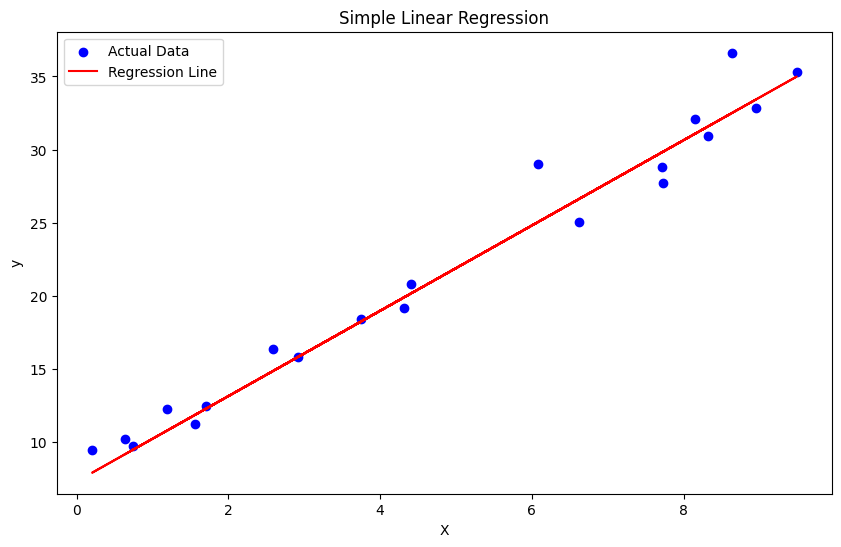

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

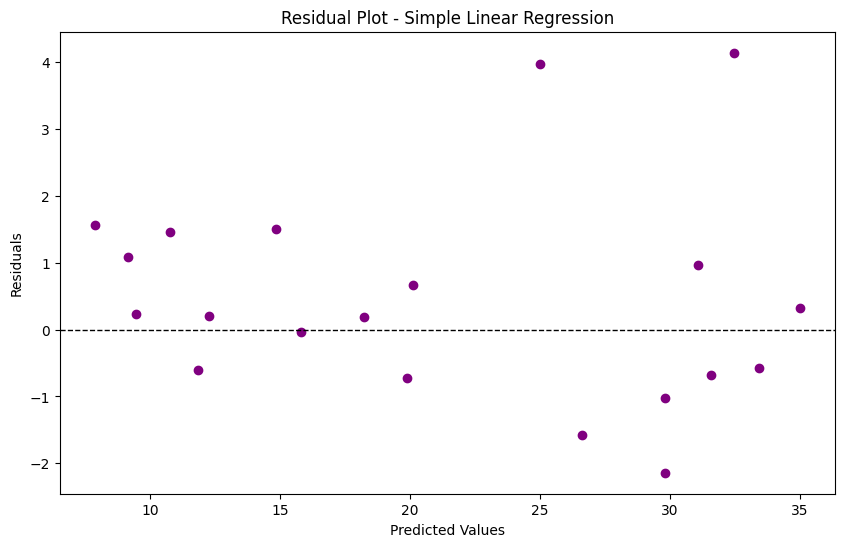

In [5]:
residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [12]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10 # 3 features
y_multi = 4 * X_multi[:, 0] + 3 * X_multi[:, 1] - 2 * X_multi[:, 2] + 5 + np.random.randn(100)

# Split the data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Build and train the multiple linear regression model
multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)

# Predict on test data
y_pred_multi = multi_lr.predict(X_test_multi)

In [13]:
# Choose one feature to plot (e.g., Feature 0)
feature_index = 0 # Index of the feature to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values

# Generate values for the selected feature
x_values = np.linspace(X_test_multi[:, feature_index].min(), X_test_multi[:, feature_index].max(), 100)

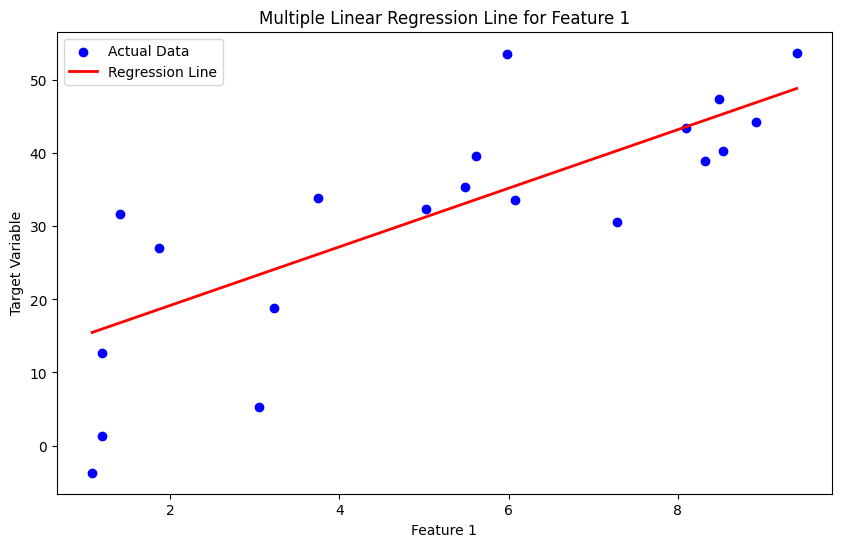

In [16]:
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x_values.shape[0], 1)) # Copy fixed features
X_plot[:, feature_index] = x_values # Replace the selected feature with varying value

# Predict using the model
y_plot = multi_lr.predict(X_plot)

# Scatter plot of actual data points for the selected feature
plt.figure(figsize=(10, 6))
plt.scatter(X_test_multi[:, feature_index], y_test_multi, color='blue', label='Actual Data')

# Plot the regression line
plt.plot(x_values, y_plot, color='red', label='Regression Line', linewidth=2)

# Add labels and title
plt.title(f'Multiple Linear Regression Line for Feature {feature_index + 1}')
plt.xlabel(f'Feature {feature_index + 1}')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

/tmp/ipykernel_5080/1605120133.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


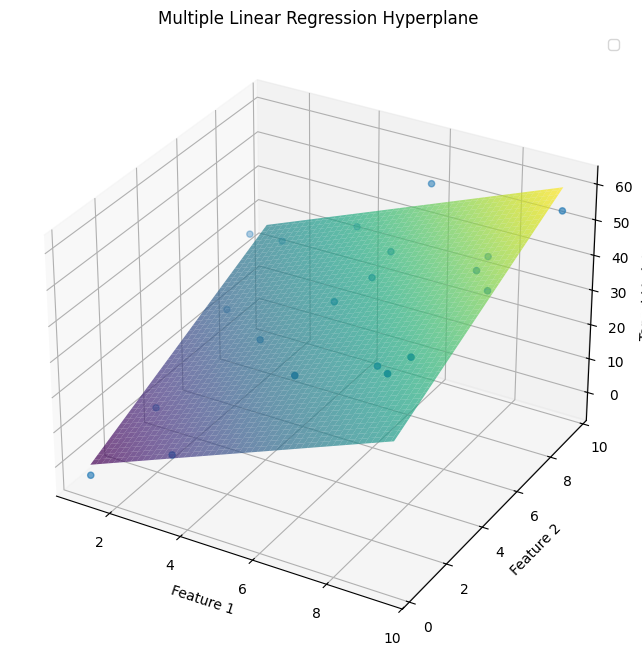

In [18]:
from mpl_toolkits.mplot3d import Axes3D

# Choose two features to plot (e.g., Features 0 and 1)
feature_indices = [0, 1] # Indices of the features to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values

# Generate a grid of values for the selected features
x1_values = np.linspace(X_test_multi[:, feature_indices[0]].min(), X_test_multi[:, feature_indices[0]].max(), 100)
x2_values = np.linspace(X_test_multi[:, feature_indices[1]].min(), X_test_multi[:, feature_indices[1]].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)

# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x1_grid.size, 1)) # Copy fixed features
X_plot[:, feature_indices[0]] = x1_grid.ravel() # Replace feature 1
X_plot[:, feature_indices[1]] = x2_grid.ravel() # Replace feature 2

# Predict using the model
y_plot = multi_lr.predict(X_plot).reshape(x1_grid.shape)
# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x1_grid, x2_grid, y_plot, cmap='viridis', alpha=0.7)

# Scatter the actual data points
ax.scatter(X_test_multi[:, feature_indices[0]], X_test_multi[:, feature_indices[1]], y_test_multi)

# Add labels and title
ax.set_title('Multiple Linear Regression Hyperplane')
ax.set_xlabel(f'Feature {feature_indices[0] + 1}')
ax.set_ylabel(f'Feature {feature_indices[1] + 1}')
ax.set_zlabel('Target Variable')
plt.legend()
plt.show()

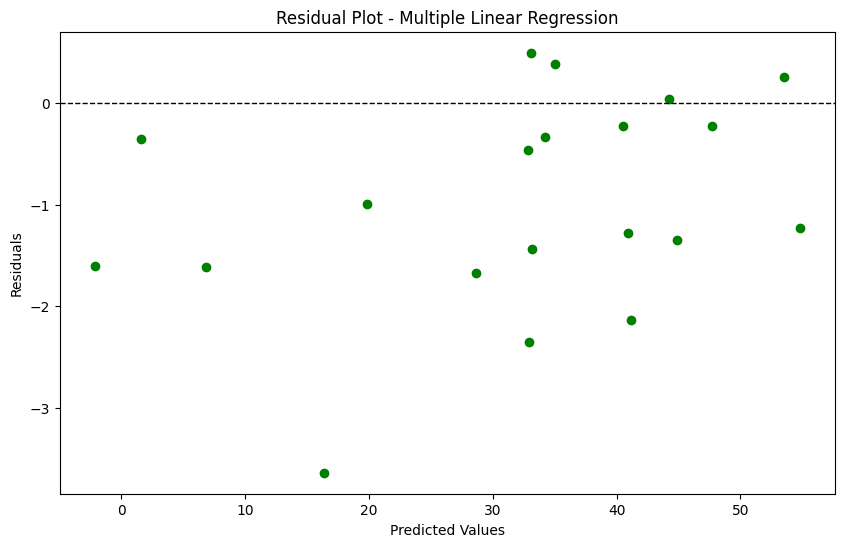

In [19]:
residuals_multi = y_test_multi - y_pred_multi
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuals_multi, color='green')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Multiple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [20]:
print("Simple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.2f}\n")
print("Multiple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test_multi, y_pred_multi):.2f}")
print(f"R2 Score: {r2_score(y_test_multi, y_pred_multi):.2f}")

Simple Linear Regression Metrics:
Mean Squared Error: 2.61
R2 Score: 0.97

Multiple Linear Regression Metrics:
Mean Squared Error: 2.02
R2 Score: 0.99


In [23]:
# for student performance report
df_raw = pd.read_csv('/content/Student_Performance.csv')

In [24]:
# check the some rows and the columns in the dataset.
df_raw.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [25]:
# make sure size of the data set is correct.
# this shows number of rows and the number of columns
df_raw.shape

(10000, 6)

In [26]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [27]:
df_raw.describe()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [28]:
# checking for duplicates
df_raw.duplicated().sum()

np.int64(127)

In [29]:
# Dropping the duplicates
df_raw.drop_duplicates(inplace=True)

In [30]:
# Checking the No and Yes are spelled the same.
df_raw['Extracurricular Activities'].value_counts()

,count
Extracurricular Activities,
No,4986
Yes,4887


In [31]:
# Need to change the Extracurricular Activities to a boolean.
# This can be done a few ways: dummy varible, replace, and where can work
# Create a new, binary column called device Extracurricular Activities called Ext_Act
df_raw['Ext Act'] = df_raw['Extracurricular Activities'].replace({'Yes':1, 'No':0})

df_raw.head()

/tmp/ipykernel_5080/344369067.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_raw['Ext Act'] = df_raw['Extracurricular Activities'].replace({'Yes':1, 'No':0})


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Ext Act
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,1
3,5,52,Yes,5,2,36.0,1
4,7,75,No,8,5,66.0,0


In [32]:
df_raw.describe()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Ext Act
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651,0.494986
std,2.589081,17.325601,1.697683,2.867202,19.208570,0.500000
min,1.000000,40.000000,4.000000,0.000000,10.000000,0.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000,0.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000,0.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000,1.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000,1.000000


([0, 1, 2],
 [Text(0, 0, 'Hours Studied'),
  Text(1, 0, 'Sleep Hours'),
  Text(2, 0, 'Sample Question Papers Practiced')])

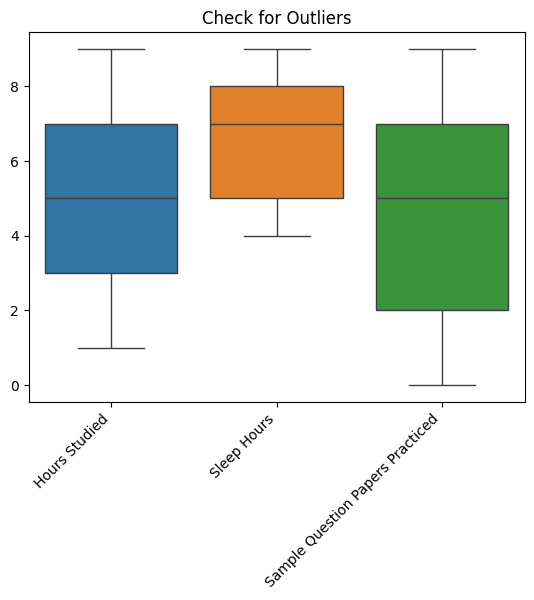

In [34]:
# Check for Outliers in the data
# One method is the use seaborn box plots with showfliers (outliers)
# Looking the dscribe can look at Hours Studied, Sleep Hours, and Sample together since they
# Pair Previous Scores and Performance Index together too.
import seaborn as sns
import matplotlib.pyplot as plt
g0 = sns.boxplot(data=df_raw[['Hours Studied','Sleep Hours','Sample Question Papers Practiced']])
g0.set_title("Check for Outliers")
plt.xticks(rotation=45, ha='right')

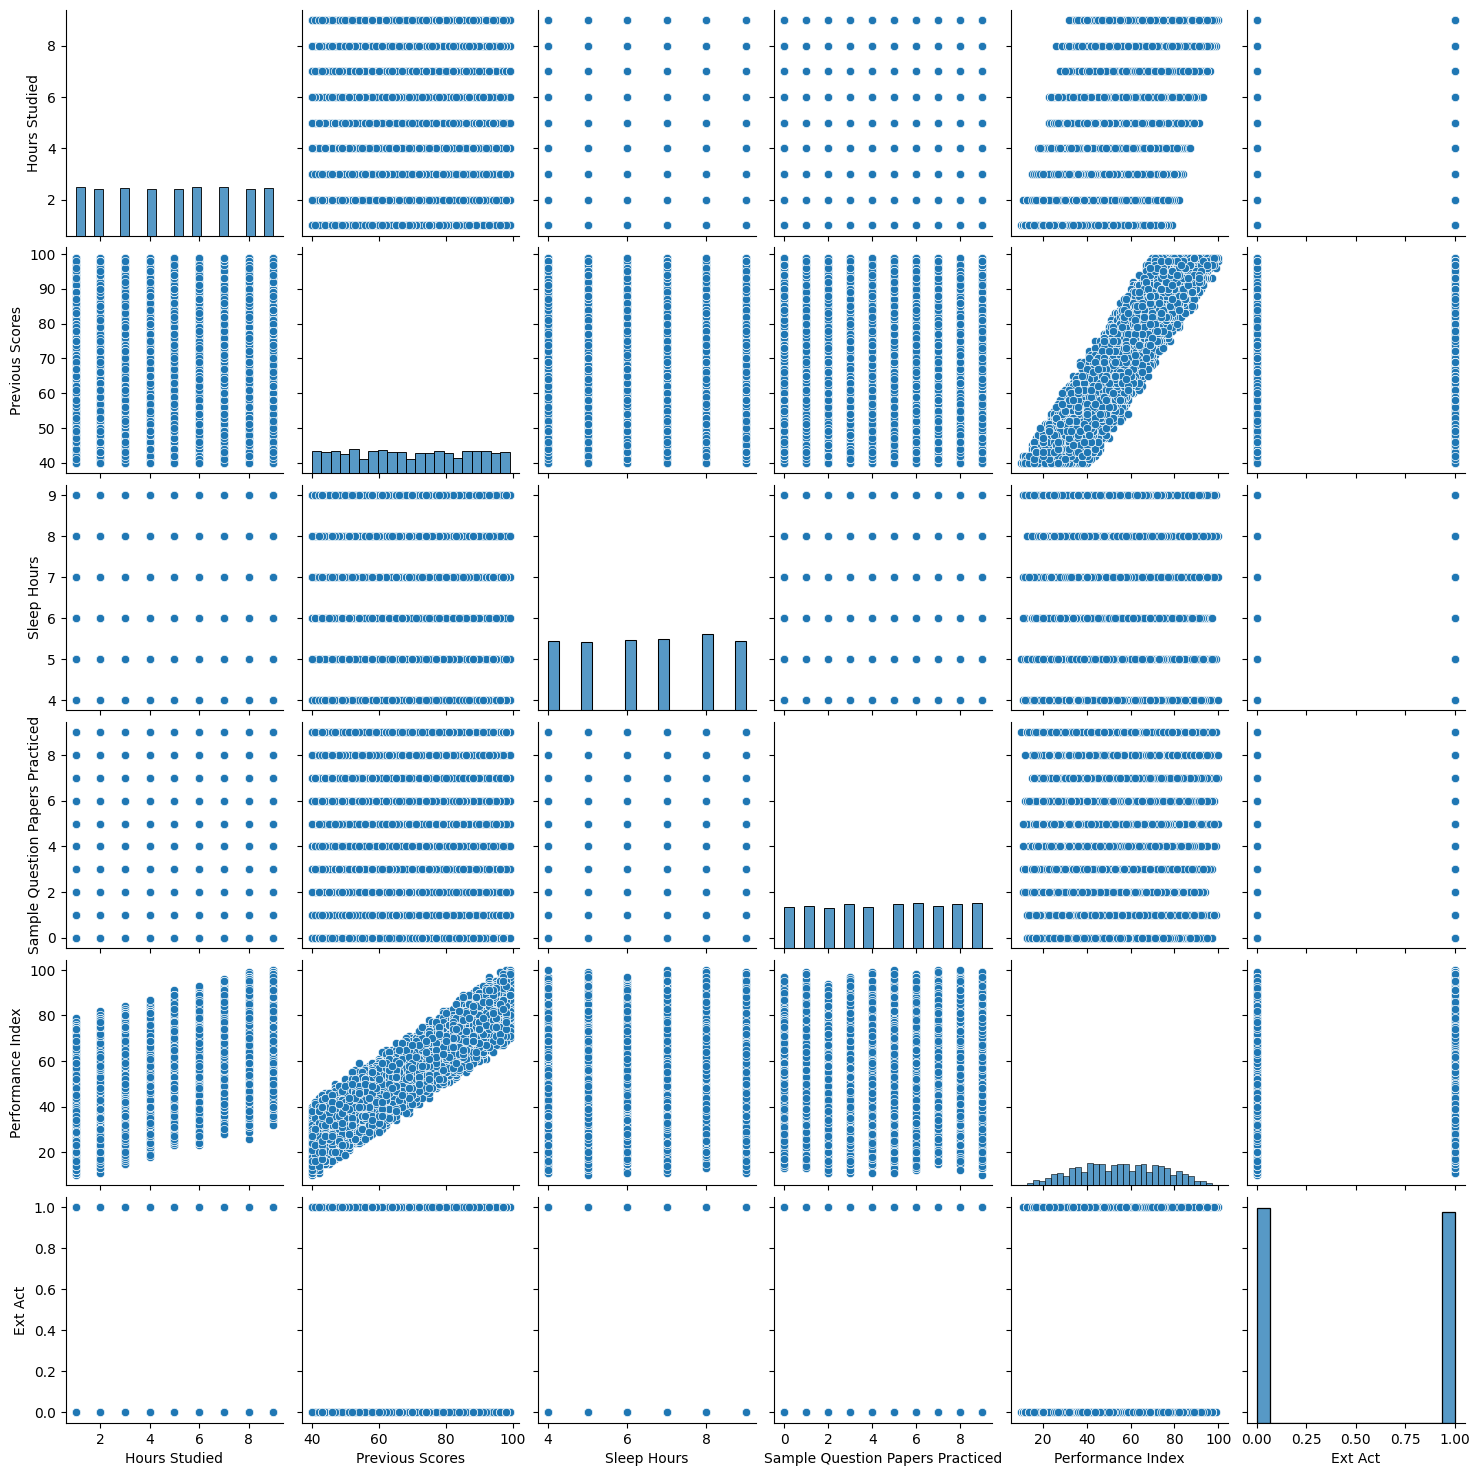

In [35]:
# Plot pairwise relationships in a dataset.
sns.pairplot(df_raw)


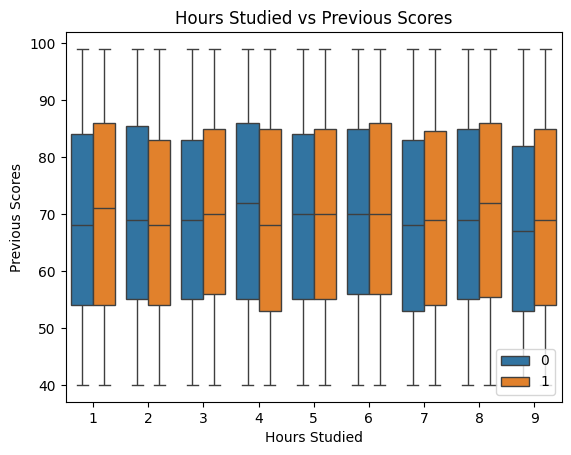

In [36]:
# Graph the Hours Studied vs. Previous Scorces
sns.boxplot(data=df_raw, x='Hours Studied', y='Previous Scores', hue='Ext Act')
plt.title('Hours Studied vs Previous Scores')
plt.legend(loc='lower right')


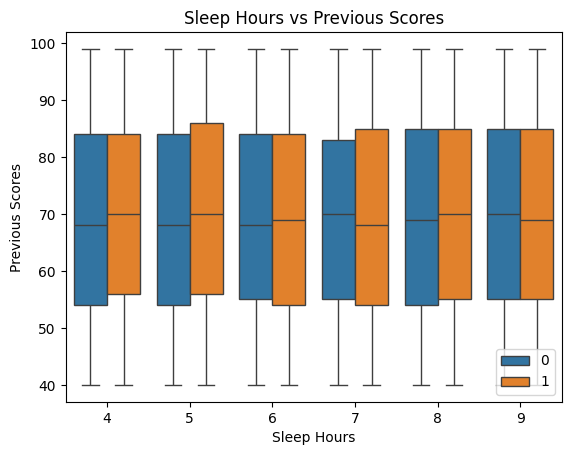

In [37]:
# Graph the Hours Sleeped vs. Previous Scorces
sns.boxplot(data=df_raw, x='Sleep Hours', y='Previous Scores', hue='Ext Act')
plt.title('Sleep Hours vs Previous Scores')
plt.legend(loc='lower right')

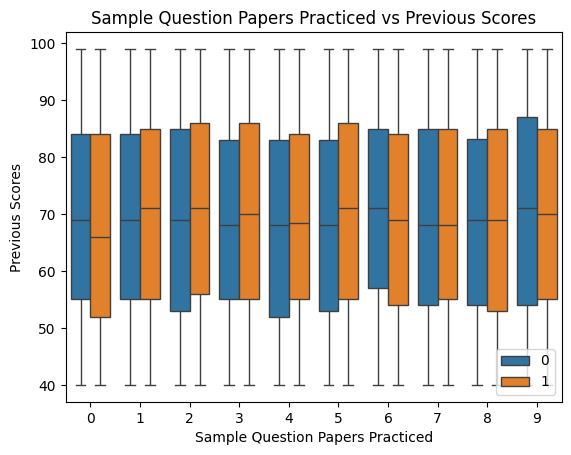

In [39]:
# Graph the Hours Studied vs. Performance Index
sns.boxplot(data=df_raw, x='Sample Question Papers Practiced', y='Previous Scores', hue='Ext Act')
plt.title('Sample Question Papers Practiced vs Previous Scores')
plt.legend(loc='lower right')

In [40]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [42]:
# coping the dataframe
df_mls = df_raw.copy()
df_mls = df_mls.drop(columns=['Ext Act'])
# Renaming the columns the for the MLS
df_mls = df_mls.rename(columns={
    "Hours Studied": "Hours_Studied",
    "Previous Scores": "Previous_Scores",
    "Sleep Hours": "Sleep_Hours",
    "Sample Question Papers Practiced": "Sample_Question_Papers_Practiced",
    "Performance Index": "Performance_Index"
})

df_mls.head()

,Hours_Studied,Previous_Scores,Extracurricular Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [43]:
# Import train-test-split function from sci-kit learn
from sklearn.model_selection import train_test_split

df_mls_y = df_mls['Performance_Index']
df_mls_X = df_mls.drop(columns=['Performance_Index'])

df_mls_X.shape , df_mls_y.shape

((9873, 5), (9873,))

In [44]:
# Create training data sets and holdout (testing) data sets
X_train, X_test, y_train, y_test = train_test_split(df_mls_X, df_mls_y, test_size = 0.3, random_state=42)

In [46]:
# Define the MLS formula.
# MLS is in the linear regression form: y ~ X+X+X
# note the column names must match to the dataframe.
# First, we have to write out the formula as a string.
# C() to indicate a categorical variable. This will tell the ols() function to one hot encoding
mls_formula = 'Performance_Index ~ Hours_Studied + Previous_Scores + C(Extracurricular_Activities)'

In [48]:
# Create MLS dataframe
mls_data = pd.concat([X_train, y_train], axis = 1)

# Rename the column to match the formula
mls_data = mls_data.rename(columns={'Extracurricular Activities': 'Extracurricular_Activities'})

# Create MLS object and fit the model
MLS = ols(formula = mls_formula, data = mls_data)
model = MLS.fit()
model_results = model.summary()

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Performance_Index   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 1.660e+05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:02:35   Log-Likelihood:                -15413.
No. Observations:                6911   AIC:                         3.083e+04
Df Residuals:                    6907   BIC:                         3.086e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                              -30.0213      0.126   -238.084      0.000     -30.268     -29.774
C(Extracurricular_Activities)[T.Yes]     0.5343      0.054      9.863      0.000       0.428       0.640
Hours_Studied                            2.8538      0.010    272.689      0.000       2.833       2.874
Previous_Scores                          1.0184      0.002    652.015      0.000       1.015       1.021
==============================================================================
Omnibus:                        2.456   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.293   Jarque-Bera (JB):                2.525
Skew:                          -0.008   Prob(JB):                        0.283
Kurtosis:                       3.092   Cond. No.                         335.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
new_data = pd.DataFrame({
'Hours_Studied': [1],
'Previous_Scores': [80],
'Extracurricular_Activities': ['No'],
'Sleep_Hours': [4],
'Sample_Question_Papers_Practiced': [1]
})
predicted_values = model.predict(new_data)
predicted_values

,0
0,54.302379


In [50]:
new_data = pd.DataFrame({
'Hours_Studied': [9],
'Previous_Scores': [80],
'Extracurricular_Activities': ['No'],
'Sleep_Hours': [4],
'Sample_Question_Papers_Practiced': [1]
})
predicted_values = model.predict(new_data)
predicted_values

,0
0,77.132931


In [51]:
new_data = pd.DataFrame({
'Hours_Studied': [5],
'Previous_Scores': [85],
'Extracurricular_Activities': ['Yes'],
'Sleep_Hours': [8],
'Sample_Question_Papers_Practiced': [5]
})
predicted_values = model.predict(new_data)
predicted_values

,0
0,71.343809


In [52]:
df_mls.columns


Index(['Hours_Studied', 'Previous_Scores', 'Extracurricular Activities',
       'Sleep_Hours', 'Sample_Question_Papers_Practiced', 'Performance_Index'],
      dtype='object')

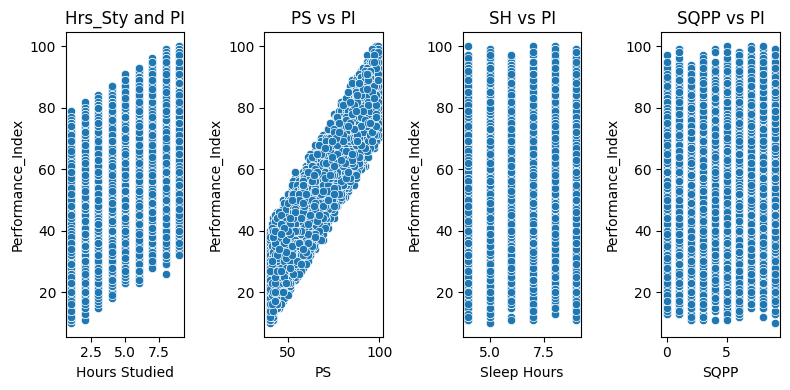

In [54]:
fig, axes = plt.subplots(1, 4, figsize = (8,4))

sns.scatterplot(x=df_mls['Hours_Studied'], y=df_mls['Performance_Index'],ax=axes[0])
axes[0].set_title("Hrs_Sty and PI")
axes[0].set_xlabel("Hours Studied")

sns.scatterplot(x=df_mls['Previous_Scores'], y=df_mls['Performance_Index'],ax=axes[1])
axes[1].set_title("PS vs PI")
axes[1].set_xlabel("PS")
sns.scatterplot(x=df_mls['Sleep_Hours'], y=df_mls['Performance_Index'],ax=axes[2])
axes[2].set_title("SH vs PI")
axes[2].set_xlabel("Sleep Hours")

sns.scatterplot(x=df_mls['Sample_Question_Papers_Practiced'], y=df_mls['Performance_Index'], ax=axes[3])
axes[3].set_title("SQPP vs PI")
axes[3].set_xlabel("SQPP")

plt.tight_layout()

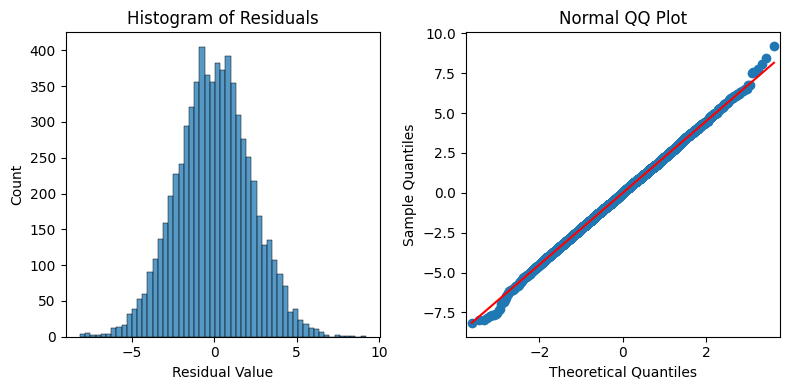

In [55]:
# Calculate residuals
residuals = model.resid

# 1 row 2 columns
fig, axes = plt.subplots(1, 2, figsize = (8,4))


# Create a Histogram plot
sns.histplot(residuals, ax=axes[0])
axes[0].set_xlabel("Residual Value")
axes[0].set_title("Histogram of Residuals")


# Create a Q-Q plot of the residuals.
sm.qqplot(model.resid, line = 's', ax=axes[1])
axes[1].set_title("Normal QQ Plot")
plt.tight_layout()
plt.show()


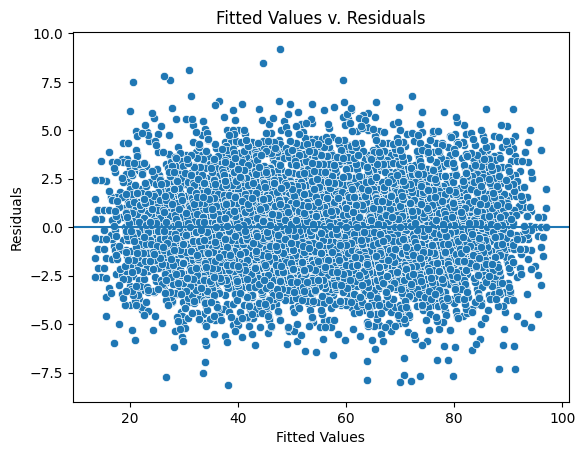

In [56]:
# Create a scatterplot with the fitted values from the model and the residuals.
fig = sns.scatterplot(x = model.fittedvalues, y = model.resid)
# Set the x-axis label.
fig.set_xlabel("Fitted Values")

# Set the y-axis label.
fig.set_ylabel("Residuals")

# Set the title.
fig.set_title("Fitted Values v. Residuals")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.
fig.axhline(0)

# Show the plot.
plt.show()

In [57]:
df_mls.columns

Index(['Hours_Studied', 'Previous_Scores', 'Extracurricular Activities',
       'Sleep_Hours', 'Sample_Question_Papers_Practiced', 'Performance_Index'],
      dtype='object')

In [58]:
df_mlsn = df_mls.copy()


In [60]:
df_mlsn['Ext_Act'] = df_mlsn['Extracurricular Activities'].replace({'Yes':1, 'No':0})

/tmp/ipykernel_5080/363110115.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mlsn['Ext_Act'] = df_mlsn['Extracurricular Activities'].replace({'Yes':1, 'No':0})
